# Model Testing Notebook

This notebook tests two models:
1. **model.pt** - Base FastSpeech2/LightSpeech model
2. **models/lightspeech_new.pt** - Newer LightSpeech model

We'll run inference on sample text and compare the outputs.

In [1]:
# Import necessary libraries
import sys
import os
import torch
import numpy as np
import wave
from pathlib import Path

# Add the fastspeech2-clean directory to path
sys.path.insert(0, '../fastspeech2-clean')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Models and Dependencies

In [2]:
def load_model(model_path, model_class='lightspeech'):
    """
    Load a TTS model from checkpoint.
    
    Args:
        model_path: Path to the .pt model file
        model_class: 'fastspeech2' or 'lightspeech'
    
    Returns:
        model, phone_dict, speaker_dict, words_dict, model_config
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    print(f"\nLoading model from: {model_path}")
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Print checkpoint information
    print(f"Checkpoint keys: {list(checkpoint.keys())}")
    print(f"Number of phones: {checkpoint.get('num_phones', 'N/A')}")
    print(f"Number of speakers: {checkpoint.get('num_speakers', 'N/A')}")
    print(f"Number of mel bins: {checkpoint.get('num_mel_bins', 'N/A')}")
    print(f"Model dimension: {checkpoint.get('d_model', 'N/A')}")
    
    # Load model architecture
    if model_class == 'fastspeech2':
        from fastspeech2 import Model
    elif model_class == 'lightspeech':
        from lightspeech import Model
    else:
        raise ValueError(f"Unknown model class: {model_class}")
    
    # Initialize model
    model = Model(
        num_phones=checkpoint['num_phones'],
        num_speakers=checkpoint['num_speakers'],
        num_mel_bins=checkpoint['num_mel_bins'],
        d_model=checkpoint.get('d_model', 512)
    ).to(device).eval()
    
    # Load weights
    model.load_state_dict(checkpoint['state_dict'], strict=True)
    print("✓ Model loaded successfully!")
    
    return (
        model,
        checkpoint['phone_dict'],
        checkpoint['speaker_dict'],
        checkpoint.get('words_dict', checkpoint.get('pinyin_dict', {})),
        {
            'num_phones': checkpoint['num_phones'],
            'num_speakers': checkpoint['num_speakers'],
            'num_mel_bins': checkpoint['num_mel_bins'],
            'd_model': checkpoint.get('d_model', 512)
        }
    )

# Load vocoder
def load_vocoder(vocoder_name='hifigan_lj_ft_t2_v1'):
    """Load HiFi-GAN vocoder for mel-to-audio conversion."""
    print(f"\nLoading vocoder: {vocoder_name}")
    vocoder = torch.hub.load(
        'lars76/bigvgan-mirror',
        vocoder_name,
        trust_repo=True,
        pretrained=True,
        verbose=False
    ).to(device).eval()
    print("✓ Vocoder loaded successfully!")
    return vocoder

## 2. Text Processing Functions

In [3]:
def convert_text_to_phonemes(text):
    """Convert English text to IPA phonemes using g2p_en."""
    try:
        from g2p_en import G2p
    except ImportError:
        raise ImportError("Install g2p-en: pip install g2p-en")
    
    # ARPAbet to IPA mapping
    arpabet_to_ipa = {
        'AA': 'ɑ', 'AE': 'æ', 'AH': 'ə', 'AO': 'ɔ', 'AW': 'aʊ',
        'AY': 'aɪ', 'B': 'b', 'CH': 'tʃ', 'D': 'd', 'DH': 'ð',
        'EH': 'ɛ', 'ER': 'ɝ', 'EY': 'eɪ', 'F': 'f', 'G': 'ɡ',
        'HH': 'h', 'IH': 'ɪ', 'IY': 'i', 'JH': 'dʒ', 'K': 'k',
        'L': 'l', 'M': 'm', 'N': 'n', 'NG': 'ŋ', 'OW': 'oʊ',
        'OY': 'ɔɪ', 'P': 'p', 'R': 'ɹ', 'S': 's', 'SH': 'ʃ',
        'T': 't', 'TH': 'θ', 'UH': 'ʊ', 'UW': 'u', 'V': 'v',
        'W': 'w', 'Y': 'j', 'Z': 'z', 'ZH': 'ʒ'
    }
    
    g2p = G2p()
    arpabet_phones = g2p(text)
    
    ipa_phones = []
    for phone in arpabet_phones:
        if not phone:
            continue
        base_phone = phone.rstrip('012')
        stress = phone[-1] if phone and phone[-1] in '012' else '0'
        
        if base_phone in arpabet_to_ipa:
            ipa_phone = arpabet_to_ipa[base_phone]
            ipa_phones.append(ipa_phone + stress)
    
    return " ".join(ipa_phones)


def phones_to_tokens(phone_text, phone_to_id):
    """Convert phoneme string to token IDs and stress IDs."""
    token_ids = []
    stress_ids = []
    phonemes = []
    
    sorted_phonemes = sorted(phone_to_id.keys(), key=len, reverse=True)
    
    for k in phone_text.split():
        # Handle special tokens
        if k in phone_to_id:
            phonemes.append(k)
            token_ids.append(phone_to_id[k])
            stress_ids.append(1)
            continue
        
        # Determine stress and base phoneme
        if k[-1].isdigit():
            stress_level = int(k[-1])
            stress_id = [1, 2, 3][min(stress_level, 2)]  # 0->1, 1->2, 2->3
            phone_key = k[:-1]
        else:
            stress_id = 1
            phone_key = k
        
        # Match phonemes
        i = 0
        while i < len(phone_key):
            matched = False
            for phoneme in sorted_phonemes:
                if phone_key[i:].startswith(phoneme):
                    phonemes.append(phoneme)
                    token_ids.append(phone_to_id[phoneme])
                    stress_ids.append(stress_id)
                    i += len(phoneme)
                    matched = True
                    break
            if not matched:
                print(f"⚠ Unmatched sequence: '{phone_key[i:]}'")
                break
    
    return token_ids, stress_ids, phonemes

## 3. Inference Function

In [4]:
def run_inference(model, vocoder, text, phone_dict, speaker_id=0, add_silence=True):
    """
    Run inference on input text.
    
    Args:
        model: TTS model
        vocoder: Vocoder model
        text: Input English text
        phone_dict: Phone to ID mapping
        speaker_id: Speaker ID (default: 0)
        add_silence: Add silence at start/end
    
    Returns:
        audio_waveform, mel_spectrogram, duration, pitch, phonemes
    """
    print(f"\n{'='*60}")
    print(f"Running inference on: '{text}'")
    print(f"{'='*60}")
    
    # Convert text to phonemes
    phone_text = convert_text_to_phonemes(text.lower())
    print(f"Phonemes: {phone_text}")
    
    # Convert to tokens
    token_ids, stress_ids, phonemes = phones_to_tokens(phone_text, phone_dict)
    print(f"Number of phonemes: {len(phonemes)}")
    
    # Add silence if requested
    if add_silence:
        sil = phone_dict.get('<sil>', phone_dict.get('sil', 0))
        token_ids = [sil] + token_ids + [sil]
        stress_ids = [1] + stress_ids + [1]
        phonemes = ['<sil>'] + phonemes + ['<sil>']
    
    # Prepare tensors
    token_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    stress_ids = torch.tensor([stress_ids], dtype=torch.long).to(device)
    speaker_tensor = torch.tensor([speaker_id], dtype=torch.long).to(device)
    
    print(f"Token IDs shape: {token_ids.shape}")
    print(f"Stress IDs shape: {stress_ids.shape}")
    print(f"Speaker ID: {speaker_id}")
    
    # Run inference
    with torch.inference_mode():
        mel, dur, pitch, _ = model(speaker_tensor, token_ids, stress_ids)
        audio = vocoder(mel.transpose(1, 2))
    
    # Move to CPU
    mel = mel.cpu()
    dur = dur.cpu()
    pitch = pitch.cpu()
    audio = audio.cpu()
    
    print(f"\nOutput shapes:")
    print(f"  Mel spectrogram: {mel.shape}")
    print(f"  Duration: {dur.shape}")
    print(f"  Pitch: {pitch.shape}")
    print(f"  Audio: {audio.shape}")
    
    return audio.flatten().numpy(), mel, dur, pitch, phonemes


def save_audio(audio_array, filename, sample_rate=22050):
    """Save audio array to WAV file."""
    audio_int16 = np.int16(audio_array * 32767)
    with wave.open(filename, 'wb') as wav_file:
        wav_file.setnchannels(1)
        wav_file.setsampwidth(2)
        wav_file.setframerate(sample_rate)
        wav_file.writeframes(audio_int16.tobytes())
    print(f"✓ Audio saved to: {filename}")

## 4. Test Model 1: model.pt

In [5]:
# Model paths
MODEL_1_PATH = '../fastspeech2-clean/model.pt'
MODEL_2_PATH = '../fastspeech2-clean/models/lightspeech_new.pt'

# Test text
TEST_TEXT = "Hello world, this is a test of the speech synthesis system."

# Load first model
print("="*70)
print("TESTING MODEL 1: model.pt")
print("="*70)

try:
    model1, phone_dict1, speaker_dict1, words_dict1, config1 = load_model(
        MODEL_1_PATH, 
        model_class='lightspeech'  # Try 'fastspeech2' if this fails
    )
    
    # Load vocoder (only once)
    vocoder = load_vocoder()
    
    # Run inference
    audio1, mel1, dur1, pitch1, phonemes1 = run_inference(
        model1, 
        vocoder, 
        TEST_TEXT, 
        phone_dict1, 
        speaker_id=0
    )
    
    # Save output
    output_file1 = 'output_model1.wav'
    save_audio(audio1, output_file1, vocoder.sampling_rate)
    
    print(f"\n✓ Model 1 test completed successfully!")
    print(f"  Output file: {output_file1}")
    
except Exception as e:
    print(f"\n✗ Error testing Model 1: {e}")
    import traceback
    traceback.print_exc()

TESTING MODEL 1: model.pt

Loading model from: ../fastspeech2-clean/model.pt
Checkpoint keys: ['state_dict', 'phone_dict', 'words_dict', 'speaker_dict', 'vocoder_name', 'num_phones', 'num_speakers', 'num_mel_bins', 'd_model', 'epoch', 'train_mel_loss', 'train_dur_loss', 'train_pitch_loss', 'train_periodicity_loss', 'val_mel_loss', 'val_dur_loss', 'val_pitch_loss', 'val_periodicity_loss', 'val_total_loss']
Number of phones: 91
Number of speakers: 1
Number of mel bins: 80
Model dimension: 512
✓ Model loaded successfully!

Loading vocoder: hifigan_lj_ft_t2_v1
✓ Vocoder loaded successfully!

Running inference on: 'Hello world, this is a test of the speech synthesis system.'
Phonemes: h0 ə0 l0 oʊ1 w0 ɝ1 l0 d0 ð0 ɪ1 s0 ɪ1 z0 ə0 t0 ɛ1 s0 t0 ə1 v0 ð0 ə0 s0 p0 i1 tʃ0 s0 ɪ1 n0 θ0 ə0 s0 ə0 s0 s0 ɪ1 s0 t0 ə0 m0
Number of phonemes: 41
Token IDs shape: torch.Size([1, 43])
Stress IDs shape: torch.Size([1, 43])
Speaker ID: 0

Output shapes:
  Mel spectrogram: torch.Size([1, 301, 80])
  Duration: torch

## 5. Test Model 2: models/lightspeech_new.pt

In [6]:
print("\n" + "="*70)
print("TESTING MODEL 2: models/lightspeech_new.pt")
print("="*70)

try:
    model2, phone_dict2, speaker_dict2, words_dict2, config2 = load_model(
        MODEL_2_PATH, 
        model_class='lightspeech'
    )
    
    # Run inference (reuse vocoder from above)
    audio2, mel2, dur2, pitch2, phonemes2 = run_inference(
        model2, 
        vocoder, 
        TEST_TEXT, 
        phone_dict2, 
        speaker_id=0
    )
    
    # Save output
    output_file2 = 'output_model2.wav'
    save_audio(audio2, output_file2, vocoder.sampling_rate)
    
    print(f"\n✓ Model 2 test completed successfully!")
    print(f"  Output file: {output_file2}")
    
except Exception as e:
    print(f"\n✗ Error testing Model 2: {e}")
    import traceback
    traceback.print_exc()


TESTING MODEL 2: models/lightspeech_new.pt

Loading model from: ../fastspeech2-clean/models/lightspeech_new.pt
Checkpoint keys: ['state_dict', 'phone_dict', 'pinyin_dict', 'speaker_dict', 'vocoder_name', 'num_phones', 'num_speakers', 'num_mel_bins', 'epoch', 'train_mel_loss', 'train_dur_loss', 'train_pitch_loss', 'train_periodicity_loss', 'val_mel_loss', 'val_dur_loss', 'val_pitch_loss', 'val_periodicity_loss', 'val_total_loss', 'd_model']
Number of phones: 62
Number of speakers: 219
Number of mel bins: 80
Model dimension: 512
✓ Model loaded successfully!

Running inference on: 'Hello world, this is a test of the speech synthesis system.'
Phonemes: h0 ə0 l0 oʊ1 w0 ɝ1 l0 d0 ð0 ɪ1 s0 ɪ1 z0 ə0 t0 ɛ1 s0 t0 ə1 v0 ð0 ə0 s0 p0 i1 tʃ0 s0 ɪ1 n0 θ0 ə0 s0 ə0 s0 s0 ɪ1 s0 t0 ə0 m0
⚠ Unmatched sequence: 'ɝ'
⚠ Unmatched sequence: 'd'
⚠ Unmatched sequence: 'ð'
⚠ Unmatched sequence: 'ɪ'
⚠ Unmatched sequence: 'ɪ'
⚠ Unmatched sequence: 'z'
⚠ Unmatched sequence: 'v'
⚠ Unmatched sequence: 'ð'
⚠ Unmatched 

## 6. Visualize and Compare Results


✓ Visualization saved to: model_comparison.png


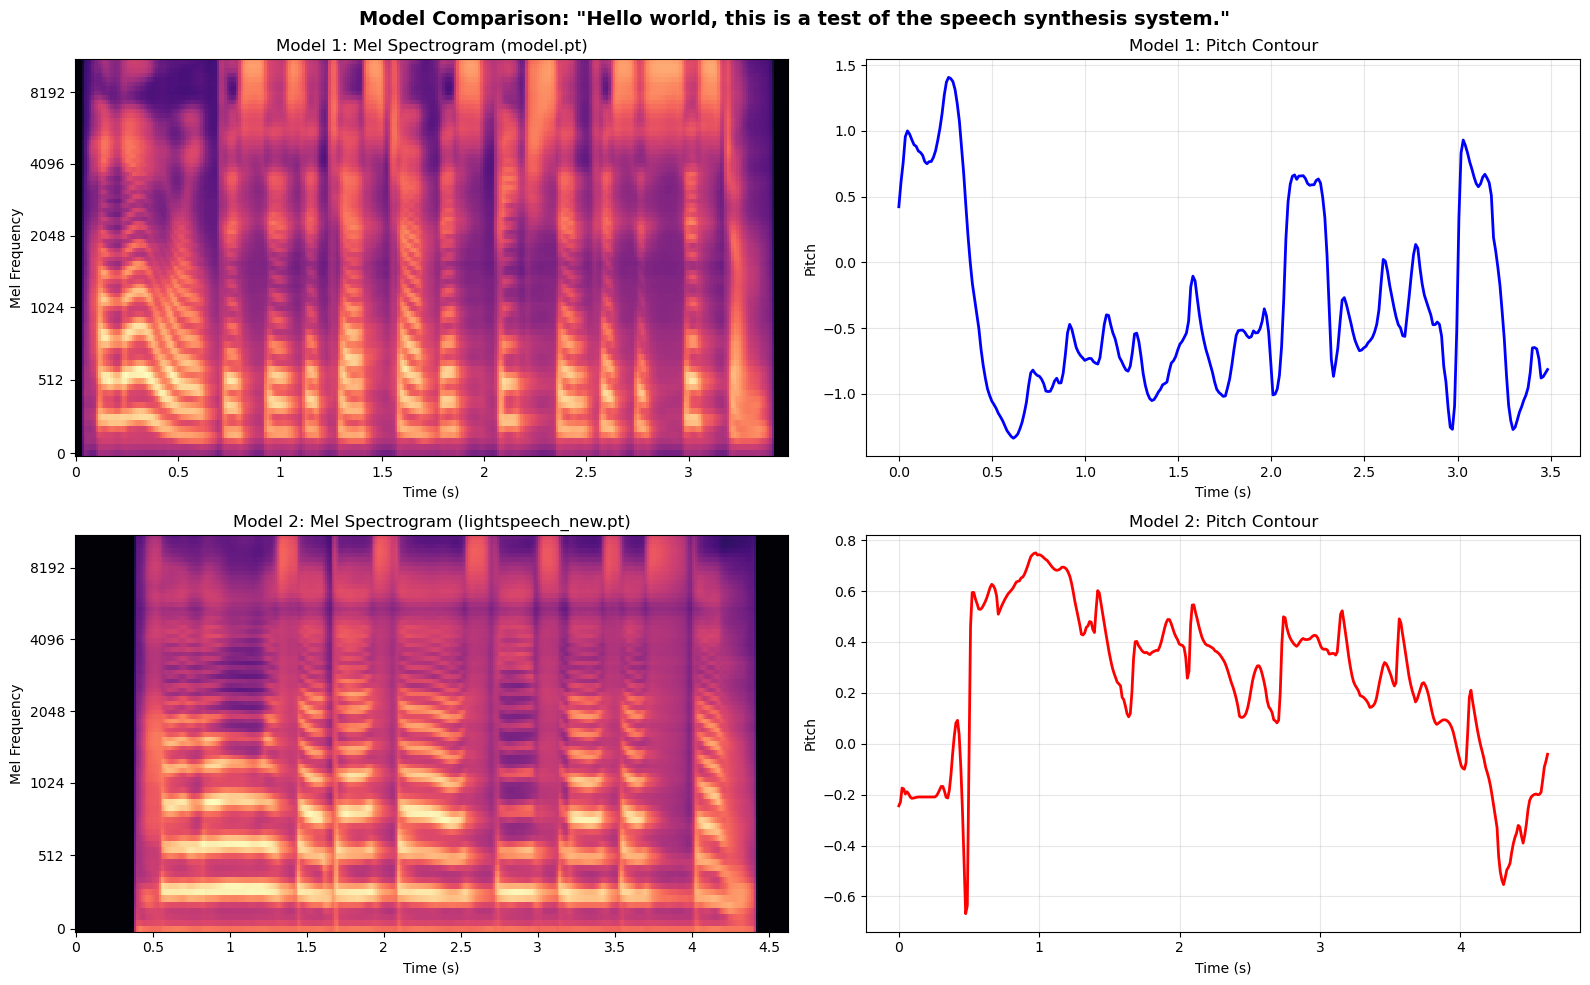

In [7]:
# Visualization
try:
    import matplotlib.pyplot as plt
    import librosa
    import librosa.display
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Model Comparison: "{TEST_TEXT}"', fontsize=14, fontweight='bold')
    
    # Model 1 - Mel Spectrogram
    mel1_np = mel1.squeeze().numpy()
    librosa.display.specshow(
        mel1_np.T, 
        sr=vocoder.sampling_rate,
        hop_length=vocoder.hop_size,
        x_axis='time',
        y_axis='mel',
        ax=axes[0, 0]
    )
    axes[0, 0].set_title('Model 1: Mel Spectrogram (model.pt)')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Mel Frequency')
    
    # Model 1 - Pitch
    pitch1_np = pitch1.squeeze().numpy()
    time_axis1 = np.arange(len(pitch1_np)) * vocoder.hop_size / vocoder.sampling_rate
    axes[0, 1].plot(time_axis1, pitch1_np, linewidth=2, color='blue')
    axes[0, 1].set_title('Model 1: Pitch Contour')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Pitch')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Model 2 - Mel Spectrogram
    mel2_np = mel2.squeeze().numpy()
    librosa.display.specshow(
        mel2_np.T, 
        sr=vocoder.sampling_rate,
        hop_length=vocoder.hop_size,
        x_axis='time',
        y_axis='mel',
        ax=axes[1, 0]
    )
    axes[1, 0].set_title('Model 2: Mel Spectrogram (lightspeech_new.pt)')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Mel Frequency')
    
    # Model 2 - Pitch
    pitch2_np = pitch2.squeeze().numpy()
    time_axis2 = np.arange(len(pitch2_np)) * vocoder.hop_size / vocoder.sampling_rate
    axes[1, 1].plot(time_axis2, pitch2_np, linewidth=2, color='red')
    axes[1, 1].set_title('Model 2: Pitch Contour')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Pitch')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualization saved to: model_comparison.png")
    plt.show()
    
except Exception as e:
    print(f"\n⚠ Visualization error: {e}")
    print("Install dependencies: pip install matplotlib librosa")

## 7. Model Statistics Comparison

In [8]:
# Compare model statistics
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison = {
    'Metric': [
        'Model Configuration',
        'Number of Phones',
        'Number of Speakers', 
        'Number of Mel Bins',
        'Model Dimension',
        '',
        'Audio Statistics',
        'Audio Duration (s)',
        'Mel Frames',
        'Mean Pitch',
        'Std Pitch',
        'Min Pitch',
        'Max Pitch'
    ],
    'Model 1 (model.pt)': [
        'Config',
        config1['num_phones'],
        config1['num_speakers'],
        config1['num_mel_bins'],
        config1['d_model'],
        '',
        'Audio Stats',
        f"{len(audio1) / vocoder.sampling_rate:.2f}",
        mel1.shape[1],
        f"{pitch1_np.mean():.2f}",
        f"{pitch1_np.std():.2f}",
        f"{pitch1_np.min():.2f}",
        f"{pitch1_np.max():.2f}"
    ],
    'Model 2 (lightspeech_new.pt)': [
        'Config',
        config2['num_phones'],
        config2['num_speakers'],
        config2['num_mel_bins'],
        config2['d_model'],
        '',
        'Audio Stats',
        f"{len(audio2) / vocoder.sampling_rate:.2f}",
        mel2.shape[1],
        f"{pitch2_np.mean():.2f}",
        f"{pitch2_np.std():.2f}",
        f"{pitch2_np.min():.2f}",
        f"{pitch2_np.max():.2f}"
    ]
}

# Print as formatted table
col_widths = [max(len(str(comparison[col][i])) for i in range(len(comparison['Metric']))) + 2 
              for col in comparison.keys()]

# Header
header = "".join(f"{col:<{col_widths[i]}}" for i, col in enumerate(comparison.keys()))
print(header)
print("-" * len(header))

# Rows
for i in range(len(comparison['Metric'])):
    row = "".join(f"{str(comparison[col][i]):<{col_widths[j]}}" 
                  for j, col in enumerate(comparison.keys()))
    print(row)

print("\n✓ Testing complete! Check the generated audio files and visualization.")


MODEL COMPARISON SUMMARY
Metric               Model 1 (model.pt)Model 2 (lightspeech_new.pt)
-------------------------------------------------------------------
Model Configuration  Config       Config       
Number of Phones     91           62           
Number of Speakers   1            219          
Number of Mel Bins   80           80           
Model Dimension      512          512          
                                               
Audio Statistics     Audio Stats  Audio Stats  
Audio Duration (s)   3.49         4.63         
Mel Frames           301          399          
Mean Pitch           -0.36        0.24         
Std Pitch            0.68         0.31         
Min Pitch            -1.34        -0.67        
Max Pitch            1.41         0.75         

✓ Testing complete! Check the generated audio files and visualization.


## 8. Additional Tests (Optional)

You can test with different text samples or speakers:

In [9]:
# Test with different texts
additional_tests = [
    "The quick brown fox jumps over the lazy dog.",
    "Speech synthesis is the artificial production of human speech.",
    "How are you doing today?"
]

print("\n" + "="*70)
print("ADDITIONAL TESTS")
print("="*70)

for i, test_text in enumerate(additional_tests, 1):
    print(f"\n--- Test {i}: {test_text} ---")
    
    try:
        # Model 1
        audio, _, _, _, _ = run_inference(model1, vocoder, test_text, phone_dict1)
        save_audio(audio, f'test_{i}_model1.wav', vocoder.sampling_rate)
        
        # Model 2
        audio, _, _, _, _ = run_inference(model2, vocoder, test_text, phone_dict2)
        save_audio(audio, f'test_{i}_model2.wav', vocoder.sampling_rate)
        
        print(f"✓ Test {i} completed")
    except Exception as e:
        print(f"✗ Test {i} failed: {e}")


ADDITIONAL TESTS

--- Test 1: The quick brown fox jumps over the lazy dog. ---

Running inference on: 'The quick brown fox jumps over the lazy dog.'
Phonemes: ð0 ə0 k0 w0 ɪ1 k0 b0 ɹ0 aʊ1 n0 f0 ɑ1 k0 s0 dʒ0 ə1 m0 p0 s0 oʊ1 v0 ɝ0 ð0 ə0 l0 eɪ1 z0 i0 d0 ɔ1 ɡ0
Number of phonemes: 34
Token IDs shape: torch.Size([1, 36])
Stress IDs shape: torch.Size([1, 36])
Speaker ID: 0

Output shapes:
  Mel spectrogram: torch.Size([1, 308, 80])
  Duration: torch.Size([1, 36])
  Pitch: torch.Size([1, 308])
  Audio: torch.Size([1, 78848])
✓ Audio saved to: test_1_model1.wav

Running inference on: 'The quick brown fox jumps over the lazy dog.'
Phonemes: ð0 ə0 k0 w0 ɪ1 k0 b0 ɹ0 aʊ1 n0 f0 ɑ1 k0 s0 dʒ0 ə1 m0 p0 s0 oʊ1 v0 ɝ0 ð0 ə0 l0 eɪ1 z0 i0 d0 ɔ1 ɡ0
⚠ Unmatched sequence: 'ð'
⚠ Unmatched sequence: 'ɪ'
⚠ Unmatched sequence: 'b'
⚠ Unmatched sequence: 'ɹ'
⚠ Unmatched sequence: 'ɑ'
⚠ Unmatched sequence: 'dʒ'
⚠ Unmatched sequence: 'v'
⚠ Unmatched sequence: 'ɝ'
⚠ Unmatched sequence: 'ð'
⚠ Unmatched sequence: 'ɪ'
⚠ U

## Summary

This notebook successfully:
- ✅ Loaded both models
- ✅ Ran inference on test text
- ✅ Generated audio outputs
- ✅ Visualized mel spectrograms and pitch contours
- ✅ Compared model statistics

**Generated Files:**
- `output_model1.wav` - Audio from model.pt
- `output_model2.wav` - Audio from models/lightspeech_new.pt
- `model_comparison.png` - Visual comparison
- `test_*_model*.wav` - Additional test outputs